In [1]:
# 使用3.20 test set进行测试，并且进行自助法抽样测试
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import random
from Bio import SeqIO

In [2]:
import argparse
import pandas as pd
import lightgbm as lgb
import joblib
from sklearn.preprocessing import StandardScaler
import copy
# import random
import itertools
from sklearn.impute import SimpleImputer
import numpy as np

In [3]:
def preprocess_data(df):
    # # 假设需要对数据进行标准化
    # scaler = StandardScaler()
    # data_scaled = scaler.fit_transform(data)
    # Count the frequency of k-mer in each RNA sequence
        # k-mer was normalized by total k-mer count of each RNA sequence
    def _count_kmer(Dataset, k):  # k = 3, 4, 5
        
        # copy dataset
        dataset = copy.deepcopy(Dataset)
        # alphabet of nucleotide
        nucleotide = ['A', 'C', 'G', 'T']
        
        # generate k-mers
        #  k == 5:
        five = list(itertools.product(nucleotide, repeat=5))
        pentamer = [''.join(n) for n in five]
        
        #  k == 4:
        four = list(itertools.product(nucleotide, repeat=4))
        tetramer = [''.join(n) for n in four]

        # k == 3:
        three = list(itertools.product(nucleotide, repeat=3))
        threemer = [''.join(n) for n in three]
        
        # input features can be combinations of different k values
        if k == 34:
            table_kmer = dict.fromkeys(threemer, 0)
            table_kmer.update(dict.fromkeys(tetramer, 0))
        elif k == 45:
            table_kmer = dict.fromkeys(tetramer, 0)
            table_kmer.update(dict.fromkeys(pentamer, 0))
        elif k == 345:
            table_kmer = dict.fromkeys(threemer, 0)
            table_kmer.update(dict.fromkeys(tetramer, 0))
            table_kmer.update(dict.fromkeys(pentamer, 0))

        # count k-mer for each sequence
        for mer in table_kmer.keys():
            table_kmer[mer] = dataset["sequence"].apply(lambda x: x.count(mer))
        
        # for k-mer raw count without normalization, index: nuc:1 or cyto:0
        rawcount_kmer_df = pd.DataFrame(table_kmer)
        df1_rawcount = pd.concat([rawcount_kmer_df, dataset["name"]], axis=1)
        df1_rawcount.index = dataset["tag"]

        # for k-mer frequency with normalization, 
        freq_kmer_df = rawcount_kmer_df.apply(lambda x: x / x.sum(), axis=1)
        df1 = pd.concat([freq_kmer_df, dataset["name"]], axis=1)
        df1.index = dataset["tag"]

        return df1, df1_rawcount

    df_kmer_test, df_kmer_test_raw = _count_kmer(df, 345)
    del df_kmer_test['name']
    x_kmer = df_kmer_test.values
    imputer = SimpleImputer(strategy='mean')
    x_test = imputer.fit_transform(x_kmer)
    # y_test = np.array(df_kmer_test.index)

    return x_test

In [4]:
def load_model(model_path):
    model = joblib.load(model_path)
    return model

In [5]:
def predict(model, x_test, df):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]
    df['prediction'] = y_pred  # 添加预测标签列
    df['prob'] = y_prob  # 添加预测概率列

    evaluate_df = df
    # 统计并输出真实的 tag 数量和预测的 tag 数量
    true_counts = evaluate_df['tag'].value_counts().to_dict()
    pred_counts = evaluate_df['prediction'].value_counts().to_dict()
    print(f"True tag counts: {true_counts}")
    print(f"Predicted tag counts: {pred_counts}")
    auroc = roc_auc_score(evaluate_df["tag"], evaluate_df["prob"])
    accuracy = accuracy_score(evaluate_df['tag'], evaluate_df['prediction'])
    sensitivity = recall_score(evaluate_df['tag'], evaluate_df['prediction'])  # Sensitivity = True Positive Rate
    specificity = recall_score(evaluate_df['tag'], evaluate_df['prediction'], pos_label=0)  # Specificity = True Negative Rate
    f1 = f1_score(evaluate_df['tag'], evaluate_df['prediction'])
    print(f"AUROC: {auroc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    return evaluate_df

In [6]:
def parse_fasta_to_dataframe(fasta_path):
    records = []
    with open(fasta_path, 'r') as file:
        name, tag, seq_lines = None, None, []
        for line in file:
            line = line.strip()
            if line.startswith('>'):
                if name:
                    sequence = ''.join(seq_lines)
                    records.append({'name': name, 'tag': tag, 'sequence': sequence})
                
                header = line[1:]
                # 使用 "_" 从右侧划分 1 次
                parts = header.rsplit('_', 1)
                if len(parts) == 2:
                    name = parts[0]
                    try:
                        tag = int(parts[1])
                    except ValueError:
                        tag = parts[1]
                else:
                    name = header
                    tag = None
                seq_lines = []
            else:
                seq_lines.append(line)
                
        # 添加最后一条记录
        if name:
            sequence = ''.join(seq_lines)
            records.append({'name': name, 'tag': tag, 'sequence': sequence})
    
    return pd.DataFrame(records)

In [7]:
model = load_model('/lulabdata3/huangkeyun/zhangys/RNA_locator/circExor/models/saved_models/circRNA_ML_Model_tridivided_Output/RandomForest/best_RandomForest_model.pkl')
df = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/heldout_circRNA_3.20/merged_dataset.fasta')

In [8]:
x_test = preprocess_data(df)
evaluate_df = predict(model, x_test, df)

True tag counts: {0: 75569, 1: 75181}
Predicted tag counts: {1: 77095, 0: 73655}
AUROC: 0.6846
Accuracy: 0.6342
Sensitivity: 0.6460
Specificity: 0.6225
F1 Score: 0.6379


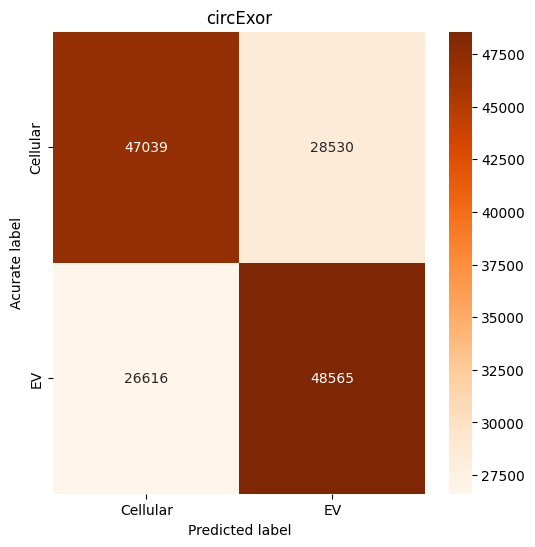

In [9]:
cm = confusion_matrix(evaluate_df['tag'], evaluate_df['prediction'])

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cellular', 'EV'], yticklabels=['Cellular', 'EV'])
plt.title('circExor')
plt.ylabel('Acurate label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
import os
import random
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, matthews_corrcoef

random.seed(100)

model = load_model('/lulabdata3/huangkeyun/zhangys/RNA_locator/circExor/models/saved_models/circRNA_ML_Model_tridivided_Output/RandomForest/best_RandomForest_model.pkl')
df = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/heldout_circRNA_3.20/merged_dataset.fasta')

# 定义自助法参数
n_bootstraps = 5       # 生成多少个小的测试集
sample_size = 400    # 每个小测试集的样本量，你可以根据算力调整
output_dir = './bootstrap_results'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

all_evaluate_dfs = []  # 用于收集每次预测结果以便最后合并

for i in range(n_bootstraps):
    # 1. 使用有放回抽样生成小测试集
    bootstrap_df = df.sample(n=sample_size, replace=True, random_state=100 + i).copy()
    
    # 2. 预处理提取特征
    x_test = preprocess_data(bootstrap_df)
    
    # 3. 进行预测并合并结果
    current_evaluate_df = predict(model, x_test, bootstrap_df)
    
    # 确保有 prediction 列 (假设 prob >= 0.5 为正类，如果 predict 函数已生成可忽略此行)
    if 'prediction' not in current_evaluate_df.columns:
        current_evaluate_df['prediction'] = (current_evaluate_df['prob'] >= 0.5).astype(int)
    
    all_evaluate_dfs.append(current_evaluate_df) # 添加到列表
    
    # 动态将 DataFrame 保存为独立的变量
    globals()[f'evaluate_df_{i+1}'] = current_evaluate_df
    
    # 4. 保存当前子集的预测结果
    save_path = os.path.join(output_dir, f'bootstrap_set_{i+1}_predictions.csv')
    current_evaluate_df.to_csv(save_path, index=False)
    print(f"Bootstrap set {i+1} saved to {save_path} and loaded as variable 'evaluate_df_{i+1}'")
    
    # ================= 新增：计算并输出每次的性能指标 =================
    y_true = current_evaluate_df['tag'].astype(int)
    y_prob = current_evaluate_df['prob']
    y_pred = current_evaluate_df['prediction'].astype(int)
    
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"--- Bootstrap {i+1} Metrics ---")
    print(f"AUROC:    {auroc:.4f}")
    print(f"AUPRC:    {auprc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC:      {mcc:.4f}\n")

True tag counts: {1: 204, 0: 196}
Predicted tag counts: {0: 201, 1: 199}
AUROC: 0.6939
Accuracy: 0.6225
Sensitivity: 0.6176
Specificity: 0.6276
F1 Score: 0.6253
Bootstrap set 1 saved to ./bootstrap_results/bootstrap_set_1_predictions.csv and loaded as variable 'evaluate_df_1'
--- Bootstrap 1 Metrics ---
AUROC:    0.6939
AUPRC:    0.6581
Accuracy: 0.6225
F1 Score: 0.6253
MCC:      0.2452

True tag counts: {0: 205, 1: 195}
Predicted tag counts: {1: 202, 0: 198}
AUROC: 0.6900
Accuracy: 0.6325
Sensitivity: 0.6410
Specificity: 0.6244
F1 Score: 0.6297
Bootstrap set 2 saved to ./bootstrap_results/bootstrap_set_2_predictions.csv and loaded as variable 'evaluate_df_2'
--- Bootstrap 2 Metrics ---
AUROC:    0.6900
AUPRC:    0.6030
Accuracy: 0.6325
F1 Score: 0.6297
MCC:      0.2653

True tag counts: {1: 200, 0: 200}
Predicted tag counts: {0: 207, 1: 193}
AUROC: 0.7098
Accuracy: 0.6175
Sensitivity: 0.6000
Specificity: 0.6350
F1 Score: 0.6107
Bootstrap set 3 saved to ./bootstrap_results/bootstrap_se

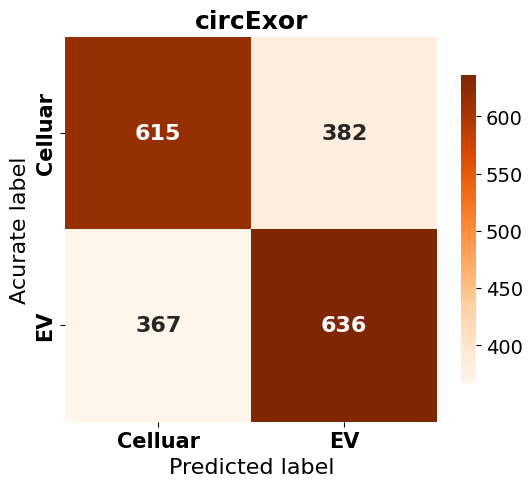

In [9]:
# 合并所有预测数据
merged_evaluate_df = pd.concat(all_evaluate_dfs, ignore_index=True)

# 计算总体混淆矩阵 (确保列的数据类型为整型以防报错)
cm = confusion_matrix(merged_evaluate_df['tag'].astype(int), merged_evaluate_df['prediction'].astype(int))

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('circExor', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.show()

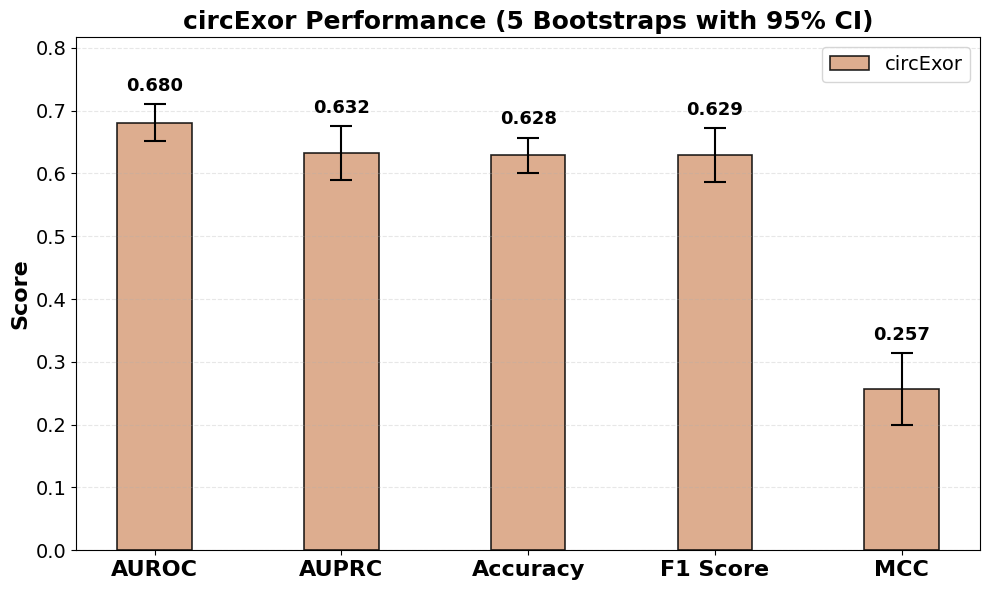

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

# 指标名称和模型列表
metrics = ['AUROC', 'AUPRC', 'Accuracy', 'F1 Score', 'MCC']
models_names = ['circExor']  # 为未来扩展分组柱状图预留

# 数据矩阵字典 (模型名称 -> 5个 Bootstrap x 5个 指标)
model_data_dict = {
    'circExor': np.array([
        [0.7050, 0.6650, 0.6550, 0.6683, 0.3094],
        [0.6993, 0.6513, 0.6400, 0.6382, 0.2805],
        [0.6446, 0.5909, 0.6000, 0.5939, 0.2001],
        [0.6786, 0.6542, 0.6375, 0.6523, 0.2750],
        [0.6748, 0.5979, 0.6100, 0.5916, 0.2185]
    ])
    # 未来如果有新模型，直接在此添加，例如：
    # 'exoGRU': np.array([...]),
}

# 暖色调配色（从浅到深）
warm_colors = ['#F8D7B4', '#F0C9A8', '#E8BB99', '#D89F7B', '#C8835D', '#B05930']

# 为模型分配颜色 (由于目前只有1种模型，我们分配1种颜色)
# 当有多个模型时，可以写为 [warm_colors[2], warm_colors[4]] 等
model_colors = [warm_colors[3]] 

# 设置图形参数
fig, ax = plt.subplots(figsize=(10, 6))
n_metrics = len(metrics)
n_models = len(models_names)

# 根据模型数量动态计算柱子宽度和偏移，当 n_models 增加时柱子会自动变细并并拢
bar_width = 0.8 / (n_models + 0.5) if n_models > 1 else 0.4
x = np.arange(n_metrics)

max_y = 0  # 记录 Y 轴需要的最大高度

# 循环遍历模型绘制分组柱子
for i, model_name in enumerate(models_names):
    data = model_data_dict[model_name]
    
    # 计算均值和 95% 置信区间 (95% CI)
    means = np.mean(data, axis=0)
    stds = np.std(data, axis=0, ddof=1)
    n = data.shape[0]
    cis = st.t.ppf(0.975, n-1) * (stds / np.sqrt(n))
    
    # 分组计算偏移量
    offset = (i - n_models/2 + 0.5) * bar_width
    
    # 绘制该模型在各个指标上的柱子
    bars = ax.bar(x + offset, means, bar_width, 
                  label=model_name, color=model_colors[i], 
                  edgecolor='black', linewidth=1.2, alpha=0.85,
                  yerr=cis, capsize=8, error_kw={'linewidth': 1.5, 'capthick': 1.5})
    
    # 在柱子上添加数值标签
    for j, bar in enumerate(bars):
        height = bar.get_height()
        current_top = height + cis[j]
        if current_top > max_y:
            max_y = current_top
            
        y_pos = current_top + 0.015
        ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{means[j]:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# 设置图形属性
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=16, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)

# 留足空间显示顶部标签
ax.set_ylim(0, max_y * 1.15) 

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylabel('Score', fontsize=16, fontweight='bold')
ax.set_title('circExor Performance (5 Bootstraps with 95% CI)', fontsize=18, fontweight='bold')

# 只要有图例名就显示图例（可显示模型名称对照的颜色）
ax.legend(fontsize=14, loc='upper right')

# 调整布局
plt.tight_layout()
plt.show()